In [1]:
import matplotlib.pyplot as plt
import numpy as np
from Tracer import solver, initial_velocity, initial_spin_rate, WindField
import Tracer.debug_tools as d

In [ ]:
from Tracer.tracer import fetch_wind_data, acc
from scipy.integrate import solve_ivp

def odesystem(t, y, W_initial, wind, decay_rate):
    # 1. Unpack the state
    P = y[:3]
    V = y[3:]
    
    # 2. Update Spin (Decay is time-dependent)
    W = W_initial * np.exp(-decay_rate * t)
    
    # 3. Get Acceleration
    # (Assuming fetch_wind_data and acc are accessible)
    wind_vec = fetch_wind_data(wind, *P)
    a = acc(V, W, wind_vec)
    
    # 4. Return derivatives: [velocity_x, y, z, acceleration_x, y, z]
    return np.concatenate([V, a])

def solver_rk45(V0, W0, P0=np.array([0, 0, 0]), wind='log', dt=0.05, decay_rate=0.05, mt=15, fast=False):
    # Similar setup as above but with fixed time steps
    # Initial state: Combine P0 and V0
    y0 = np.concatenate([P0, V0])

    if not isinstance(wind, WindField) and wind == 'log' or wind == 'uniform':
        wind = WindField(nx=30, ny=150, nz=50, direction=45, profile=wind, z0=0.003, U_ref=10) # Assuming this is defined somewhere
    # Define the 'Ground Hit' event to stop the solver early
    
    def hit_ground(t, y, *args):
        return y[2] # The Z-coordinate
    hit_ground.terminal = True
    hit_ground.direction = -1

    t_requested = None if fast else np.arange(0, 15, dt)

    sol = solve_ivp(
        odesystem, 
        t_span=(0, mt),       # Max time 15 seconds
        y0=y0, 
        method='RK45',        # Dormand-Prince adaptive solver
        args=(W0, wind, decay_rate),
        events=hit_ground,    # Stops the moment Z hits 0
        t_eval=t_requested,
        rtol=1e-5, atol=1e-8  # Precision settings
    )

    # Accessing results:
    t_steps = sol.t
    positions = sol.y[:3, :].T # Shape (N, 3)
    velocities = sol.y[3:, :].T
    spin_rates = W0 * np.exp(-decay_rate * t_steps[:, np.newaxis])

    return t_steps, positions, velocities, spin_rates



In [3]:
V0 = initial_velocity(40, 25) # 40 m/s at 25 degrees
W0 = initial_spin_rate(8500) # 8500 rpm

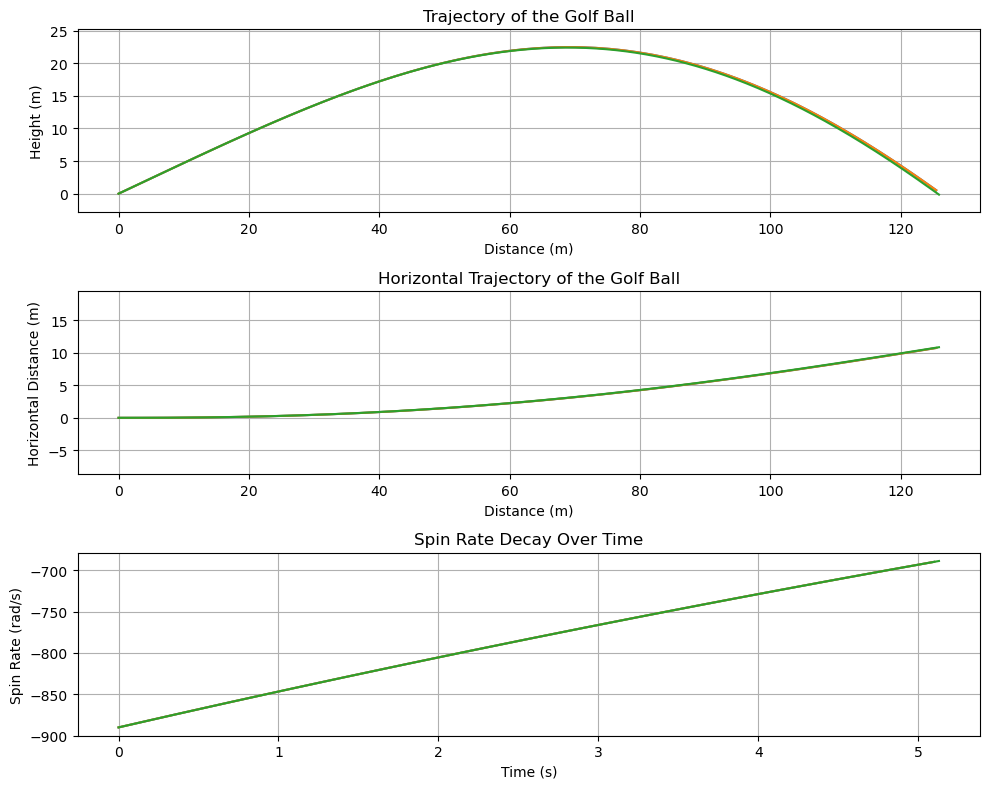

In [14]:
d.plot_trajectories([solver_rk45(V0, W0, dt=0.05), solver_rk45(V0, W0, dt=0.1), solver(V0, W0, dt=0.01)])

In [17]:
def run_convergence_test():
    # 1. Establish "Truth" (Very small dt)
    print("Calculating Truth...")
    p_truth = solver(V0, W0, dt=0.0001)[1]
    truth_point = p_truth[-1]
    print(f"Truth Landing Point: {truth_point}")
    # p_truth = solver_rk45(V0, W0, dt=0.1)[1]
    # truth_point = p_truth[-1]
    # print(f"Truth Landing Point: {truth_point}")

    dts = [0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]
    errors_euler = []
    errors_rk45 = []

    for d in dts:
        # Test Euler (your current solver)
        print(f"Running Euler with dt={d}...")
        p_e = solver(V0, W0, dt=d)[1]
        p_r = solver_rk45(V0, W0, dt=d)[1]
        errors_euler.append(np.linalg.norm(p_e[-1] - truth_point))
        errors_rk45.append(np.linalg.norm(p_r[-1] - truth_point))


        
    # 3. Log-Log Plot
    plt.figure(figsize=(10, 6))
    plt.loglog(dts, errors_euler, 'o-', label='Euler (Native Python)')
    plt.loglog(dts, errors_rk45, 's-', label='RK45 (SciPy)')
    # Add slope reference lines (theoretical convergence)
    plt.loglog(dts, [d**1 * 100 for d in dts], '--', color='gray', alpha=0.5, label='Order 1 (Slope 1)')
    plt.loglog(dts, [d**4 * 1000 for d in dts], '--', color='darkgray', alpha=0.5, label='Order 4 (Slope 4)')
    plt.yticks([1e-9, 1e-6, 1e-3, 1e-2, 1], ['1 nm', '1 μm', '1 mm', '1 cm', '1 m'])

    plt.title("Solver Precision: Landing Point Error vs dt")
    plt.xlabel("Step Size (dt) [log]")
    plt.ylabel("Final Position Error (m) [log]")
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.show()


Calculating Truth...
Truth Landing Point: [ 1.26157765e+02  1.08267513e+01 -3.08008475e-06]
Running Euler with dt=0.2...
Running Euler with dt=0.1...
Running Euler with dt=0.05...
Running Euler with dt=0.02...
Running Euler with dt=0.01...
Running Euler with dt=0.005...
Running Euler with dt=0.002...
Running Euler with dt=0.001...


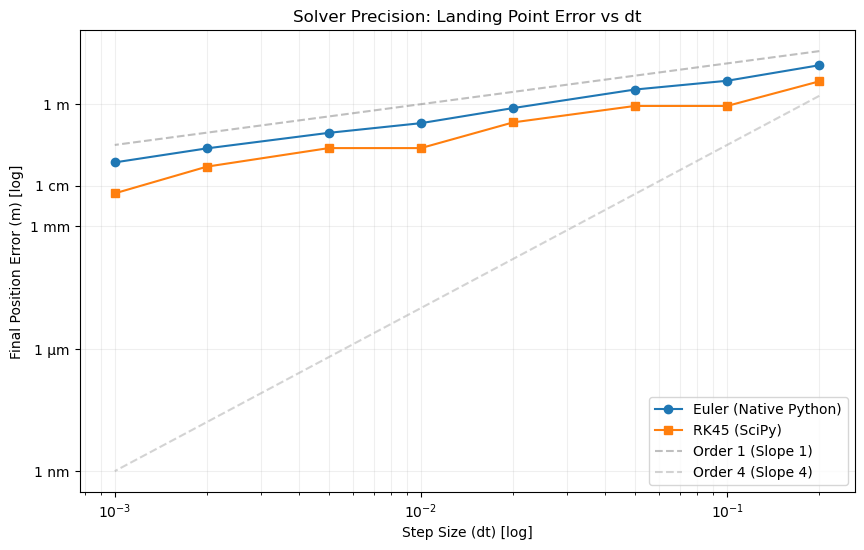

In [18]:
run_convergence_test()